In [37]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [38]:
print(torch.__version__)

2.13.0+cu126


In [39]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backend.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"using device = {device}")

using device = cuda


In [61]:
from sklearn.datasets import make_circles
X,y = make_circles(n_samples=1000,noise=0.04,random_state=42)

print(f"Shape of x and y: {X.shape,y.shape}")

Shape of x and y: ((1000, 2), (1000,))


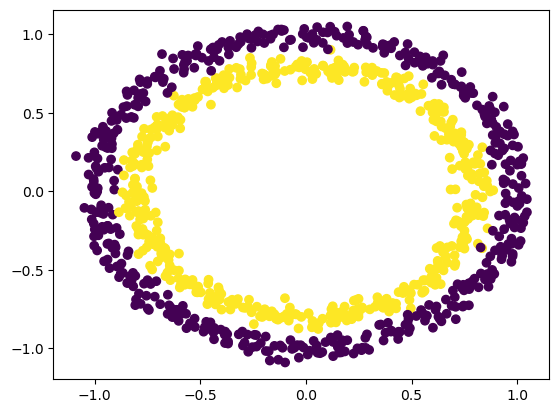

In [62]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [40]:
from sklearn.datasets import make_moons


X,y = make_moons(n_samples=1000,noise=0.04,random_state=42)

print(f"Shape of x and y: {X.shape,y.shape}")

Shape of x and y: ((1000, 2), (1000,))


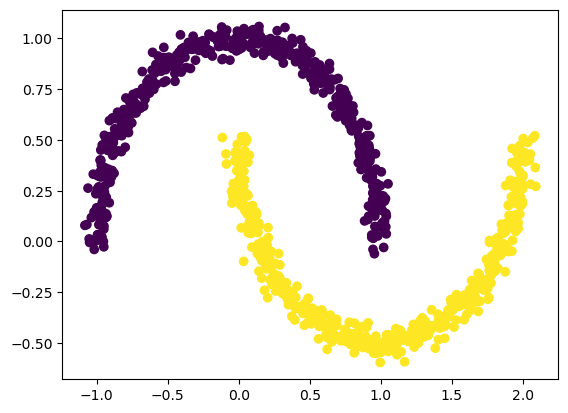

In [41]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

In [42]:
# convert the data into tensors 

from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [43]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
# define the model 
from torch import nn
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=10)
        self.layer_2 = nn.Linear(in_features=10,out_features=10)
        self.layer_3 = nn.Linear(in_features=10,out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [45]:
# instantiate the model and inspect parameters 
model = CircleModel()
print(model.state_dict()[
    'layer_1.weight'
].size())

torch.Size([10, 2])


In [46]:
# define loss function and optimizer 
#bce = binary cross entropy

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.05)

In [47]:
# defin accuracy function 
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_true))*100
    return acc

In [58]:
# training loop 
epochs = 5000 
train_loss_list = []
test_loss_list = []

torch.manual_seed(42)

model.to(device)

X_train,y_train = X_train.to(device),y_train.to(device)
X_test ,y_test = X_test.to(device),y_test.to(device)


for epoch in range(epochs):
    model.train()
    
    #forward pass
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # last layer ma sigmoid laune initial ma relu haru hunxa
    
    # compute loss 
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true= y_train,y_pred=y_pred)
    
    #optimizer zero grad 
    optimizer.zero_grad()
    
    #back propagate 
    loss.backward()
    
    #step the optimizer 
    optimizer.step()
    
    #testing 
    
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred = test_preds)
    
    train_loss_list.append(loss.item())
    test_loss_list.append(test_loss.item())
    

    if (epoch+1) % 100 == 0:
        print(f"Epochs {epoch+1} | Loss {loss:.5f} | Acc {acc:.2f} | Test loss {test_loss:.5f} | Test Acc {test_acc:.3f}")

Epochs 100 | Loss 0.08949 | Acc 96.88 | Test loss 0.08185 | Test Acc 98.500
Epochs 200 | Loss 0.07189 | Acc 98.25 | Test loss 0.06483 | Test Acc 99.000
Epochs 300 | Loss 0.05754 | Acc 99.00 | Test loss 0.05133 | Test Acc 99.500
Epochs 400 | Loss 0.04646 | Acc 99.25 | Test loss 0.04101 | Test Acc 99.500
Epochs 500 | Loss 0.03813 | Acc 99.62 | Test loss 0.03323 | Test Acc 100.000
Epochs 600 | Loss 0.03190 | Acc 99.88 | Test loss 0.02752 | Test Acc 100.000
Epochs 700 | Loss 0.02711 | Acc 100.00 | Test loss 0.02321 | Test Acc 100.000
Epochs 800 | Loss 0.02336 | Acc 100.00 | Test loss 0.01985 | Test Acc 100.000
Epochs 900 | Loss 0.02039 | Acc 100.00 | Test loss 0.01722 | Test Acc 100.000
Epochs 1000 | Loss 0.01799 | Acc 100.00 | Test loss 0.01508 | Test Acc 100.000
Epochs 1100 | Loss 0.01604 | Acc 100.00 | Test loss 0.01335 | Test Acc 100.000
Epochs 1200 | Loss 0.01442 | Acc 100.00 | Test loss 0.01193 | Test Acc 100.000
Epochs 1300 | Loss 0.01307 | Acc 100.00 | Test loss 0.01075 | Test Acc 

Text(0.5, 1.0, 'epochs vs loss')

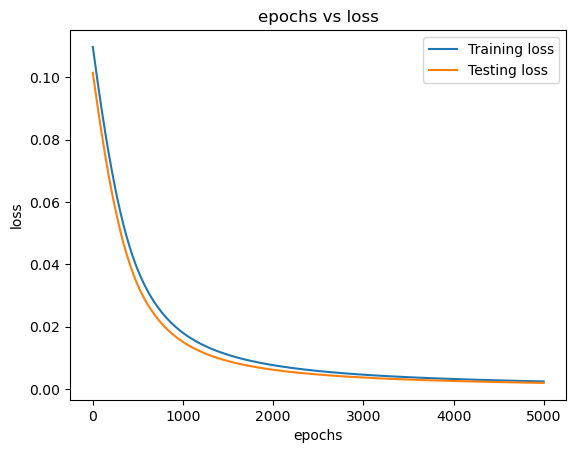

In [59]:
#plot loss cureve 

plt.plot(range(epochs),train_loss_list,label="Training loss")
plt.plot(range(epochs),test_loss_list,label = "Testing loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.title("epochs vs loss")

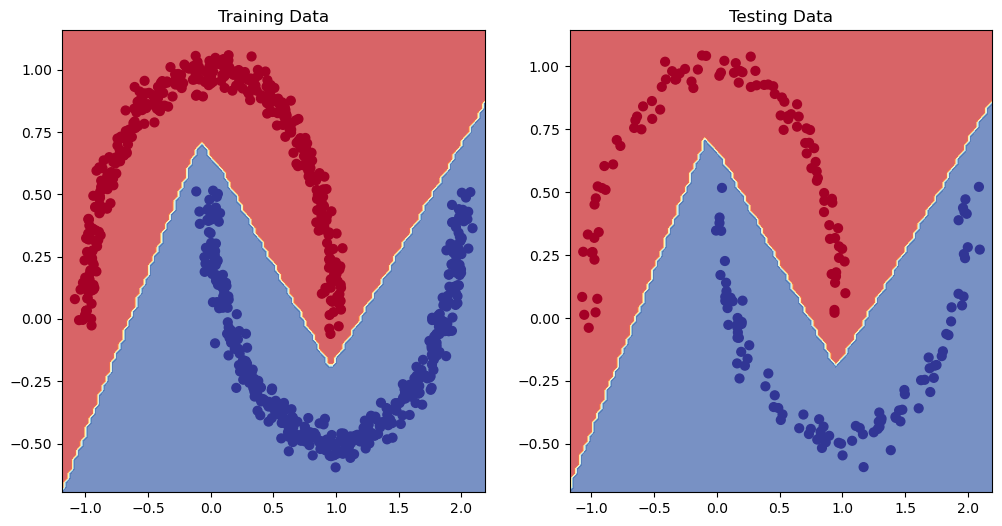

In [60]:
from helper import plot_decision_boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Training Data")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Testing Data")
plot_decision_boundary(model, X_test, y_test)